In [49]:
import pandas as pd

df = df = pd.read_csv("data/activities.csv")

In [50]:
df.shape

(1701, 103)

In [51]:
df.head()

,Activity ID,Activity Date,Activity Name,Activity Type,Activity Description,Elapsed Time,Distance,Max Heart Rate,Relative Effort,Commute,...,Recovery,With Pet,Competition,Long Run,For a Cause,With Kid,Downhill Distance,Total Sets,Total Reps,Media
0,18106757338,"Apr 14, 2026, 3:42:53 PM",Evening Trail Run,Run,NaN,2659,7.10,192.0,41.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,18105679507,"Apr 13, 2026, 9:41:09 AM",Lunch Trail Run,Run,NaN,3371,7.58,174.0,48.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,18105677469,"Apr 12, 2026, 4:29:54 PM",Evening Trail Run,Run,NaN,2217,4.03,175.0,23.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,18069008013,"Apr 11, 2026, 2:46:11 PM",Afternoon Trail Run,Run,NaN,5940,7.66,173.0,24.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,18066572272,"Apr 10, 2026, 2:51:29 PM",Afternoon Trail Run,Run,NaN,3549,6.79,167.0,26.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [52]:
df["Activity Type"].value_counts()

Activity Type
Run                  1260
Swim                  124
Ride                  116
Weight Training        75
Workout                56
Stand Up Paddling      35
Hike                   21
Crossfit               10
Walk                    3
Rock Climb              1
Name: count, dtype: int64

In [53]:
df = df[df["Activity Type"] == "Run"]

In [54]:
df.shape

(1260, 103)

In [55]:
df.columns

Index(['Activity ID', 'Activity Date', 'Activity Name', 'Activity Type',
       'Activity Description', 'Elapsed Time', 'Distance', 'Max Heart Rate',
       'Relative Effort', 'Commute',
       ...
       'Recovery', 'With Pet', 'Competition', 'Long Run', 'For a Cause',
       'With Kid', 'Downhill Distance', 'Total Sets', 'Total Reps', 'Media'],
      dtype='str', length=103)

In [56]:
columns_to_keep = [
    "Activity Date",
    "Activity Name",
    "Distance",
    "Elapsed Time",
    "Moving Time",
    "Max Heart Rate",
    "Relative Effort",
    "Elevation Gain"
]

df = df[columns_to_keep]

In [57]:
df.shape

(1260, 8)

In [58]:
df.dtypes

Activity Date          str
Activity Name          str
Distance               str
Elapsed Time         int64
Moving Time        float64
Max Heart Rate     float64
Relative Effort    float64
Elevation Gain     float64
dtype: object

In [59]:
df["Distance"] = pd.to_numeric(df["Distance"], errors="coerce")

In [60]:
df["Pace_min_per_km"] = (df["Moving Time"] / 60) / df["Distance"]

In [61]:
df["Efficiency"] = df["Pace_min_per_km"] / df["Max Heart Rate"]

In [62]:
df["Activity Date"] = pd.to_datetime(
    df["Activity Date"],
    format="%b %d, %Y, %I:%M:%S %p"
)

In [63]:
df.dtypes

Activity Date      datetime64[us]
Activity Name                 str
Distance                  float64
Elapsed Time                int64
Moving Time               float64
Max Heart Rate            float64
Relative Effort           float64
Elevation Gain            float64
Pace_min_per_km           float64
Efficiency                float64
dtype: object

In [64]:
df["week"] = df["Activity Date"].dt.isocalendar().week

In [65]:
df["year"] = df["Activity Date"].dt.year

In [66]:
df[["Activity Date", "year", "week"]].head()

,Activity Date,year,week
0,2026-04-14 15:42:53,2026,16
1,2026-04-13 09:41:09,2026,16
2,2026-04-12 16:29:54,2026,15
3,2026-04-11 14:46:11,2026,15
4,2026-04-10 14:51:29,2026,15


In [67]:
weekly_df = df.groupby(["year", "week"]).agg({
    "Distance": "sum",
    "Pace_min_per_km": "mean"
}).reset_index()

In [68]:
df["Max Heart Rate"].isna().sum()

np.int64(772)

In [69]:
df_hr = df[df["Max Heart Rate"].notna()]

In [70]:
df_hr.shape

(488, 12)

In [71]:
weekly_hr_df = df_hr.groupby(["year", "week"]).agg({
    "Distance": "sum",
    "Pace_min_per_km": "mean",
    "Efficiency": "mean"
}).reset_index()

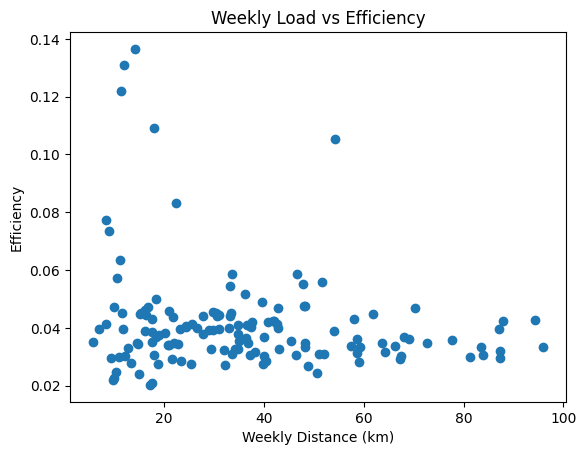

In [72]:
import matplotlib.pyplot as plt

plt.scatter(weekly_hr_df["Distance"], weekly_hr_df["Efficiency"])
plt.xlabel("Weekly Distance (km)")
plt.ylabel("Efficiency")
plt.title("Weekly Load vs Efficiency")
plt.show()

In [73]:
weekly_hr_df[["Distance", "Efficiency"]].isna().sum()

Distance      0
Efficiency    0
dtype: int64

In [74]:
import numpy as np
weekly_hr_df = weekly_hr_df[~np.isinf(weekly_hr_df["Efficiency"])]
weekly_hr_df = weekly_hr_df.sort_values(["year", "week"])

In [75]:
np.isinf(weekly_hr_df["Efficiency"]).sum()

np.int64(0)

In [76]:
weekly_hr_df["Distance"].corr(weekly_hr_df["Efficiency"])

np.float64(-0.19160248819853964)

In [77]:
weekly_hr_df.groupby("year")["Efficiency"].mean()

year
2019    0.029948
2020    0.028435
2021    0.032721
2023    0.039499
2024    0.041255
2025    0.047432
2026    0.049427
Name: Efficiency, dtype: float64

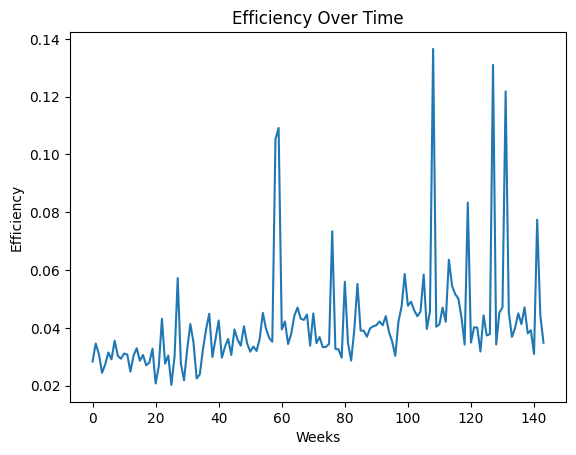

In [78]:
weekly_hr_df = weekly_hr_df.sort_values(["year", "week"])

plt.plot(weekly_hr_df["Efficiency"])
plt.title("Efficiency Over Time")
plt.xlabel("Weeks")
plt.ylabel("Efficiency")
plt.show()

In [79]:
df["elevation_per_km"] = df["Elevation Gain"] / df["Distance"] 

In [80]:
weekly_df = df.groupby(["year", "week"]).agg({
    "Distance": "sum",
    "Pace_min_per_km": "mean",
    "elevation_per_km": "mean"
}).reset_index()

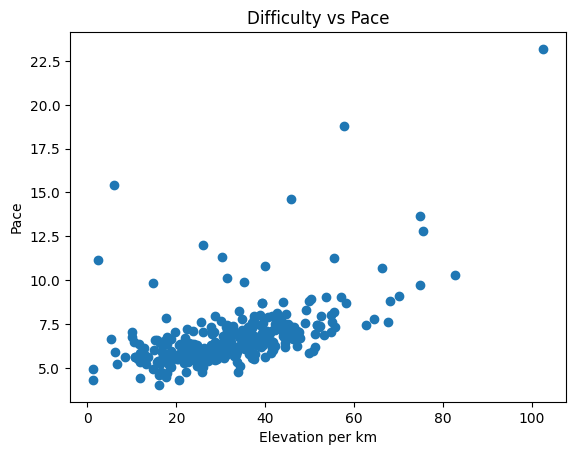

In [81]:
plt.scatter(weekly_df["elevation_per_km"], weekly_df["Pace_min_per_km"])
plt.xlabel("Elevation per km")
plt.ylabel("Pace")
plt.title("Difficulty vs Pace")
plt.show()

In [82]:
df[["Distance", "Elevation Gain", "elevation_per_km"]].head()

,Distance,Elevation Gain,elevation_per_km
0,7.10,98.0,13.802817
1,7.58,259.0,34.168865
2,4.03,38.0,9.429280
3,7.66,302.0,39.425587
4,6.79,234.0,34.462445


In [83]:
df["difficulty_level"] = pd.cut(
    df["elevation_per_km"],
    bins=[0, 15, 30, 100],
    labels=["Easy", "Medium", "Hard"]
)

In [84]:
df.groupby("difficulty_level")["Pace_min_per_km"].mean()

difficulty_level
Easy      5.977900
Medium    5.835614
Hard      7.713824
Name: Pace_min_per_km, dtype: float64

In [85]:
df.groupby(["year", "difficulty_level"])["Pace_min_per_km"].mean()

year  difficulty_level
2018  Easy                5.409879
      Medium              4.693488
      Hard                6.953060
2019  Easy                5.469205
      Medium              5.780547
      Hard                6.560747
2020  Easy                4.920232
      Medium              5.285897
      Hard                6.294392
2021  Easy                5.295823
      Medium              5.544015
      Hard                6.820892
2022  Easy                5.537634
      Medium              5.811800
      Hard                7.668884
2023  Easy                5.246408
      Medium              5.649757
      Hard                7.675618
2024  Easy                6.199801
      Medium              6.117477
      Hard                8.349259
2025  Easy                6.873034
      Medium              6.539786
      Hard                8.429089
2026  Easy                7.893199
      Medium              7.133733
      Hard                8.852797
Name: Pace_min_per_km, dtype: fl

In [86]:
df.groupby(["year", "difficulty_level"])["Distance"].mean()

year  difficulty_level
2018  Easy                 5.629000
      Medium              16.486000
      Hard                13.189091
2019  Easy                12.068000
      Medium              12.880000
      Hard                12.458333
2020  Easy                12.129000
      Medium              14.693571
      Hard                10.545833
2021  Easy                11.489697
      Medium              13.180566
      Hard                11.867778
2022  Easy                10.249333
      Medium              12.299444
      Hard                12.157500
2023  Easy                12.243684
      Medium              12.833906
      Hard                12.203289
2024  Easy                 9.295965
      Medium              12.717222
      Hard                13.793882
2025  Easy                 5.700541
      Medium              10.032000
      Hard                 9.913978
2026  Easy                 7.245263
      Medium               9.665000
      Hard                 7.435625
Name:

In [87]:
df.groupby(["year", "difficulty_level"]).size()

year  difficulty_level
2018  Easy                 10
      Medium                5
      Hard                 11
2019  Easy                 45
      Medium               47
      Hard                 54
2020  Easy                 10
      Medium               14
      Hard                 12
2021  Easy                 33
      Medium               53
      Hard                 45
2022  Easy                 15
      Medium               72
      Hard                116
2023  Easy                 19
      Medium               64
      Hard                149
2024  Easy                 57
      Medium               54
      Hard                 85
2025  Easy                 37
      Medium               35
      Hard                 93
2026  Easy                 19
      Medium                4
      Hard                 16
dtype: int64

In [88]:
df.groupby(["year", "difficulty_level"])["Pace_min_per_km"].median()

year  difficulty_level
2018  Easy                4.925440
      Medium              4.397271
      Hard                6.622946
2019  Easy                5.303426
      Medium              5.960636
      Hard                6.398019
2020  Easy                4.986579
      Medium              5.088349
      Hard                6.074475
2021  Easy                5.216142
      Medium              5.527873
      Hard                6.774892
2022  Easy                5.433333
      Medium              5.508253
      Hard                7.667971
2023  Easy                5.164609
      Medium              5.414405
      Hard                7.232181
2024  Easy                5.761374
      Medium              6.003637
      Hard                7.542579
2025  Easy                6.725664
      Medium              6.080174
      Hard                7.717391
2026  Easy                6.050524
      Medium              7.121502
      Hard                7.900751
Name: Pace_min_per_km, dtype: fl

In [89]:
df.groupby(["year", "difficulty_level"])["Distance"].median()

year  difficulty_level
2018  Easy                 5.475
      Medium              16.710
      Hard                11.500
2019  Easy                10.590
      Medium              12.070
      Hard                12.045
2020  Easy                11.870
      Medium              16.040
      Hard                10.550
2021  Easy                10.380
      Medium              12.500
      Hard                11.140
2022  Easy                10.640
      Medium              11.110
      Hard                11.315
2023  Easy                11.340
      Medium              12.210
      Hard                10.860
2024  Easy                 8.310
      Medium              11.820
      Hard                12.100
2025  Easy                 5.700
      Medium              10.410
      Hard                 8.610
2026  Easy                 7.100
      Medium              10.205
      Hard                 7.520
Name: Distance, dtype: float64

In [90]:
weekly_df.to_csv("weekly_data.csv", index=False)